# Unified micro-climate real-time model - 3 day

Predicts the five micro-climate variables needed before the root-zone model:
- internal air temperature
- ET0
- internal relative humidity
- internal radiation
- soil temperature

The notebook keeps the existing 3-day walk-forward setup: 10 days of 10-minute samples for the initial training window, 3-day prediction blocks, and expanding training after each block. It uses a pruned operational feature set from external weather/radiation and target-specific training rows so soil-temperature gaps do not remove rows for the other targets.


In [5]:
# Repo paths (works even when notebook is in scripts/)
from pathlib import Path

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / 'data').exists():
            return p
    return start


ROOT = find_repo_root()
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
PLOTS = ROOT / 'plots' / 'micro climate results'
PROCESSED.mkdir(exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)


In [6]:
import numpy as np
import pandas as pd

TRAIN_WINDOW = 1440  # 10 days of 10-minute samples
TEST_WINDOW = 432    # 3 days of 10-minute samples
MAX_TRAIN_ROWS = None
MIN_TRAIN_ROWS_PER_TARGET = 200

TARGETS = [
    'internal_air_temp_c',
    'ET0',
    'internal_rh_pct',
    'internal_radiation',
    'soil_temp_C',
]

OUTPUT_PREFIX = 'MicroClimate' 


In [7]:
# Load raw files
weather_path = RAW / 'bet_dagan_weather.csv'
radiation_path = RAW / 'bet_dagan_radiation.csv'
micro_path = PROCESSED / 'micro_climate_rh_t_et0.xlsx'
soil_path = RAW / 'Data Final OG.csv'

weather = pd.read_csv(weather_path)
radiation = pd.read_csv(radiation_path)
micro = pd.read_excel(micro_path).rename(columns={
    'internal_rh_%': 'internal_rh_pct',
    'Rs, MJ/m2/10mins': 'rs_mj_m2_10min',
    'Rn, MJ/m2/10mins (day/night)': 'rn_mj_m2_10min_daynight',
    'G,MJ/m2/h(day/night)': 'g_mj_m2_h_daynight',
    'u2 (m/s/10mins)': 'u2_ms_10min',
})
soil = pd.read_csv(soil_path)

# Replace Hebrew headers with ASCII names based on column order for reproducibility.
weather.columns = [
    'station', 'timestamp', 'station_pressure_hpa', 'rel_humidity_ext', 'temp_c_ext',
    'temp_max_c_ext', 'temp_min_c_ext', 'temp_ground_c_ext', 'temp_wet_c_ext',
    'wind_dir_deg', 'gust_dir_deg', 'wind_speed_ms', 'wind_speed_max_1m_ms',
    'wind_speed_max_10m_ms', 'wind_speed_max_10m_time', 'gust_speed_ms', 'wind_dir_std_deg',
]
radiation.columns = ['rad_station', 'timestamp', 'diffuse_rad_wm2', 'global_rad_wm2', 'direct_rad_wm2']
weather = weather.drop(columns=['station'])
radiation = radiation.drop(columns=['rad_station'])

# Robust timestamp parsing, matching the previous notebook behavior.
# The workbook mixes day-first strings and Excel datetime objects; casting to string then
# parsing day-first preserves the continuous 10-minute campaign sequence.
micro_ts_text = micro['timestamp_dayfirst'].astype(str).str.strip()
micro['timestamp'] = pd.to_datetime(micro_ts_text, dayfirst=True, format='mixed', errors='coerce')
micro = micro.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

expected_start = pd.Timestamp('2025-05-29 01:00:00')
micro = micro[micro['timestamp'] >= expected_start].reset_index(drop=True)

weather['timestamp'] = pd.to_datetime(weather['timestamp'], dayfirst=True, format='mixed', errors='coerce')
radiation['timestamp'] = pd.to_datetime(radiation['timestamp'], dayfirst=True, format='mixed', errors='coerce')
weather = weather.dropna(subset=['timestamp'])
radiation = radiation.dropna(subset=['timestamp'])

# Soil logger target.
soil['timestamp'] = pd.to_datetime(
    soil['datetime'].astype(str) + ' ' + soil['time'].astype(str),
    dayfirst=False,
    errors='coerce',
)
soil = soil[['timestamp', 'soil_temp_C']].dropna(subset=['timestamp', 'soil_temp_C'])
soil['soil_temp_C'] = pd.to_numeric(soil['soil_temp_C'], errors='coerce')
soil = soil.dropna(subset=['soil_temp_C']).groupby('timestamp', as_index=False)['soil_temp_C'].mean()

# Convert numeric columns after parsing timestamps.
for df in (weather, radiation, micro):
    for col in df.columns:
        if col not in ('timestamp', 'timestamp_dayfirst'):
            df[col] = pd.to_numeric(df[col], errors='coerce')

weather = weather.drop(columns=[c for c in weather.columns if weather[c].isna().all()])
radiation = radiation.drop(columns=[c for c in radiation.columns if radiation[c].isna().all()])

print('Micro target span:', micro['timestamp'].min(), '->', micro['timestamp'].max(), 'rows:', len(micro))
print('Soil target span:', soil['timestamp'].min(), '->', soil['timestamp'].max(), 'rows:', len(soil))
print('Weather span:', weather['timestamp'].min(), '->', weather['timestamp'].max(), 'rows:', len(weather))
print('Radiation span:', radiation['timestamp'].min(), '->', radiation['timestamp'].max(), 'rows:', len(radiation))


Micro target span: 2025-05-29 01:00:00 -> 2025-09-21 23:00:00 rows: 16682
Soil target span: 2025-08-10 12:30:00 -> 2025-09-19 18:10:00 rows: 4306
Weather span: 2025-05-29 00:00:00 -> 2025-09-21 23:00:00 rows: 16690
Radiation span: 2025-05-29 00:00:00 -> 2025-09-21 23:00:00 rows: 16698


In [8]:
# Feature engineering

def calculate_saturation_vapor_pressure(temp_c):
    return 0.61078 * np.exp((17.27 * temp_c) / (temp_c + 237.3))


def calculate_vpd(temp_c, rh_pct):
    es = calculate_saturation_vapor_pressure(temp_c)
    ea = es * (rh_pct / 100.0)
    return es - ea


def calculate_absolute_humidity(temp_c, rh_pct):
    return (6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5)) * rh_pct * 2.1674) / (273.15 + temp_c)


weather['vpd_ext'] = calculate_vpd(weather['temp_c_ext'], weather['rel_humidity_ext'])
weather['abs_humidity_ext'] = calculate_absolute_humidity(weather['temp_c_ext'], weather['rel_humidity_ext'])
weather['dew_point_ext'] = weather['temp_c_ext'] - ((100 - weather['rel_humidity_ext']) / 5)

target_frame = micro.merge(soil, on='timestamp', how='outer')
merged = target_frame.merge(weather, on='timestamp', how='left').merge(radiation, on='timestamp', how='left')

full_range = pd.date_range(merged['timestamp'].min(), merged['timestamp'].max(), freq='10min')
model_frame = merged.set_index('timestamp').reindex(full_range)
model_frame.index.name = 'timestamp'
model_frame = model_frame.reset_index()

exogenous_cols = [c for c in model_frame.columns if c not in TARGETS + ['timestamp', 'timestamp_dayfirst']]
model_frame = model_frame.set_index('timestamp')
model_frame[exogenous_cols] = model_frame[exogenous_cols].interpolate(method='time').bfill().ffill()
model_frame = model_frame.reset_index()

OUTLIER_INTERVALS = [
    (pd.Timestamp('2025-09-11 00:00'), pd.Timestamp('2025-09-11 10:50')),
    (pd.Timestamp('2025-09-18 06:00'), pd.Timestamp('2025-09-18 09:00')),
    (pd.Timestamp('2025-08-27 08:00'), pd.Timestamp('2025-08-27 14:00')),
    (pd.Timestamp('2025-08-28 08:00'), pd.Timestamp('2025-08-28 11:00')),
]
for start, end in OUTLIER_INTERVALS:
    model_frame = model_frame[(model_frame['timestamp'] < start) | (model_frame['timestamp'] > end)]
model_frame = model_frame.sort_values('timestamp').reset_index(drop=True)

model_frame['hour_of_day'] = model_frame['timestamp'].dt.hour
model_frame['day_of_year'] = model_frame['timestamp'].dt.dayofyear
hour_float = model_frame['timestamp'].dt.hour + model_frame['timestamp'].dt.minute / 60.0
model_frame['hour_sin'] = np.sin(2 * np.pi * hour_float / 24.0)
model_frame['hour_cos'] = np.cos(2 * np.pi * hour_float / 24.0)
model_frame['doy_sin'] = np.sin(2 * np.pi * model_frame['day_of_year'] / 365.25)
model_frame['doy_cos'] = np.cos(2 * np.pi * model_frame['day_of_year'] / 365.25)

smooth_cols = ['global_rad_wm2', 'diffuse_rad_wm2', 'direct_rad_wm2', 'temp_c_ext', 'rel_humidity_ext']
for c in smooth_cols:
    if c in model_frame.columns:
        model_frame[f'{c}_med6'] = model_frame[c].rolling(window=6, min_periods=1).median()

if {'temp_c_ext', 'rel_humidity_ext'}.issubset(model_frame.columns):
    model_frame['vpd_ext_calc'] = calculate_vpd(model_frame['temp_c_ext'], model_frame['rel_humidity_ext'])
    model_frame['dew_point_ext_calc'] = model_frame['temp_c_ext'] - ((100 - model_frame['rel_humidity_ext']) / 5)
    model_frame['dewpoint_gradient'] = model_frame['dew_point_ext_calc'] - model_frame['temp_c_ext']

if 'vpd_ext_calc' in model_frame.columns:
    model_frame['vpd_ext_rolling_mean_30min'] = model_frame['vpd_ext_calc'].rolling(window=3, min_periods=1).mean()
    model_frame['vpd_ext_min_1h'] = model_frame['vpd_ext_calc'].rolling(window=6, min_periods=1).min()

if 'global_rad_wm2' in model_frame.columns:
    model_frame['rad_integral_1h'] = model_frame['global_rad_wm2'].rolling(window=6, min_periods=1).sum()
    model_frame['rad_peak_intensity'] = model_frame['global_rad_wm2'].rolling(window=6, min_periods=1).max()
    model_frame['rad_slope_30m'] = model_frame['global_rad_wm2'].diff(periods=3)
    model_frame['rad_slope_1h'] = model_frame['global_rad_wm2'].diff(periods=6)
    model_frame['rad_is_low'] = model_frame['global_rad_wm2'] <= 5
    model_frame['sunrise_flag'] = (~model_frame['rad_is_low']) & (model_frame['rad_is_low'].shift(1, fill_value=True))
    model_frame['sunset_flag'] = model_frame['rad_is_low'] & (~model_frame['rad_is_low'].shift(1, fill_value=False))
    sunrise_groups = model_frame['sunrise_flag'].cumsum()
    sunset_groups = model_frame['sunset_flag'].cumsum()
    model_frame['minutes_since_sunrise'] = model_frame.groupby(sunrise_groups).cumcount() * 10
    model_frame.loc[model_frame['rad_is_low'], 'minutes_since_sunrise'] = np.nan
    model_frame['minutes_since_sunset'] = model_frame.groupby(sunset_groups).cumcount() * 10
    model_frame.loc[~model_frame['rad_is_low'], 'minutes_since_sunset'] = np.nan

# Pruned from the 40-feature operational set by full-data LightGBM gain importance.
# Removed: wind_speed_ms, direct_rad_wm2_med6, vpd_ext_calc, dew_point_ext_calc,
# rad_is_low, sunrise_flag, sunset_flag.
# RH keeps this exact 33-feature setup; soil temperature adds four cyclic time features.
BASE_FEATURE_COLS = [
    'station_pressure_hpa',
    'rel_humidity_ext',
    'temp_c_ext',
    'temp_max_c_ext',
    'temp_min_c_ext',
    'temp_ground_c_ext',
    'wind_dir_deg',
    'gust_dir_deg',
    'wind_speed_max_1m_ms',
    'wind_speed_max_10m_ms',
    'gust_speed_ms',
    'wind_dir_std_deg',
    'vpd_ext',
    'abs_humidity_ext',
    'dew_point_ext',
    'diffuse_rad_wm2',
    'global_rad_wm2',
    'direct_rad_wm2',
    'hour_of_day',
    'day_of_year',
    'global_rad_wm2_med6',
    'diffuse_rad_wm2_med6',
    'temp_c_ext_med6',
    'rel_humidity_ext_med6',
    'dewpoint_gradient',
    'vpd_ext_rolling_mean_30min',
    'vpd_ext_min_1h',
    'rad_integral_1h',
    'rad_peak_intensity',
    'rad_slope_30m',
    'rad_slope_1h',
    'minutes_since_sunrise',
    'minutes_since_sunset',
]

SOIL_CYCLIC_FEATURE_COLS = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
ALL_FEATURE_COLS = BASE_FEATURE_COLS + SOIL_CYCLIC_FEATURE_COLS

missing_features = [c for c in ALL_FEATURE_COLS if c not in model_frame.columns]
if missing_features:
    raise ValueError(f'Missing expected feature columns: {missing_features}')

base_feature_cols = [c for c in BASE_FEATURE_COLS if not model_frame[c].isna().all()]
soil_feature_cols = [c for c in ALL_FEATURE_COLS if not model_frame[c].isna().all()]
feature_cols = soil_feature_cols
feature_cols_by_target = {target: base_feature_cols for target in TARGETS}
feature_cols_by_target['soil_temp_C'] = soil_feature_cols
bad_feature_chars = ['{', '}', '[', ']', ':', ',', '"']
bad_feature_cols = [c for c in feature_cols if any(ch in c for ch in bad_feature_chars)]
if bad_feature_cols:
    raise ValueError(f'LightGBM-incompatible feature names: {bad_feature_cols}')

print(f'Model frame rows: {len(model_frame):,}')
print(f'Base feature count: {len(base_feature_cols)}')
print(f'Soil feature count: {len(soil_feature_cols)}')
display(model_frame[TARGETS].notna().sum().rename('target_rows').to_frame())
model_frame.head()


Model frame rows: 16,552
Base feature count: 33
Soil feature count: 37


,target_rows
internal_air_temp_c,16541
ET0,16541
internal_rh_pct,16541
internal_radiation,16541
soil_temp_C,4231


,timestamp,timestamp_dayfirst,ET0,internal_air_temp_c,internal_rh_pct,internal_radiation,rs_mj_m2_10min,rn_mj_m2_10min_daynight,g_mj_m2_h_daynight,u2_ms_10min,...,vpd_ext_min_1h,rad_integral_1h,rad_peak_intensity,rad_slope_30m,rad_slope_1h,rad_is_low,sunrise_flag,sunset_flag,minutes_since_sunrise,minutes_since_sunset
0,2025-05-29 01:00:00,29/05/2025 01:00:00,0.014021,22.775547,74.709380,0.0,0.0,0.0,0.0,3.467081,...,0.764606,0.0,0.0,NaN,NaN,True,False,True,NaN,0.0
1,2025-05-29 01:10:00,29/05/2025 01:10:00,0.013813,22.743830,74.193410,0.0,0.0,0.0,0.0,3.467081,...,0.759937,0.0,0.0,NaN,NaN,True,False,False,NaN,10.0
2,2025-05-29 01:20:00,29/05/2025 01:20:00,0.011687,22.473650,73.349106,0.0,0.0,0.0,0.0,3.256955,...,0.755292,0.0,0.0,NaN,NaN,True,False,False,NaN,20.0
3,2025-05-29 01:30:00,29/05/2025 01:30:00,0.012145,22.452467,71.715630,0.0,0.0,0.0,0.0,3.151892,...,0.755292,0.0,0.0,0.0,NaN,True,False,False,NaN,30.0
4,2025-05-29 01:40:00,29/05/2025 01:40:00,0.006759,22.511518,71.976640,0.0,0.0,0.0,0.0,1.575946,...,0.746077,0.0,0.0,0.0,NaN,True,False,False,NaN,40.0


In [9]:
# Model and expanding walk-forward helpers
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import joblib

base_estimator = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.04,
    num_leaves=80,
    max_depth=-1,
    min_child_samples=35,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

rh_estimator = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.04,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=55,
    subsample=0.75,
    subsample_freq=1,
    colsample_bytree=0.65,
    reg_lambda=4.0,
    reg_alpha=0.4,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

soil_estimator = LGBMRegressor(
    objective='huber',
    alpha=0.8,
    n_estimators=500,
    learning_rate=0.04,
    num_leaves=48,
    max_depth=-1,
    min_child_samples=25,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_lambda=1.5,
    reg_alpha=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


def estimator_for_target(target):
    if target == 'internal_rh_pct':
        return rh_estimator
    if target == 'soil_temp_C':
        return soil_estimator
    return base_estimator


def feature_cols_for_target(target):
    return feature_cols_by_target.get(target, feature_cols)


def clip_predictions(target, preds):
    if target == 'internal_rh_pct':
        return np.clip(preds, 0, 100)
    if target in ('ET0', 'internal_radiation'):
        return np.clip(preds, 0, None)
    return preds


def safe_r2(y_true, y_pred):
    if len(y_true) < 2 or np.nanstd(y_true) == 0:
        return np.nan
    return r2_score(y_true, y_pred)


def walk_forward(df, feature_cols, targets, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, max_train_rows=MAX_TRAIN_ROWS):
    metrics = []
    pred_blocks = []
    train_end = train_window
    test_end = train_end + test_window
    run = 0

    while test_end <= len(df):
        train_start_idx = max(0, train_end - max_train_rows) if max_train_rows else 0
        train = df.iloc[train_start_idx:train_end]
        test = df.iloc[train_end:test_end]

        metric = {
            'run': run,
            'train_start': train['timestamp'].iloc[0],
            'train_end': train['timestamp'].iloc[-1],
            'test_start': test['timestamp'].iloc[0],
            'test_end': test['timestamp'].iloc[-1],
            'train_rows': len(train),
            'test_rows': len(test),
        }
        pred_block = test[['timestamp'] + targets].reset_index(drop=True).copy()

        print(
            f"Run {run}: train {len(train)} rows ({metric['train_start']} -> {metric['train_end']}), "
            f"test {len(test)} rows ({metric['test_start']} -> {metric['test_end']})"
        )

        for target in targets:
            train_t = train.dropna(subset=[target])
            test_actual = test.dropna(subset=[target])
            pred_col = f'pred_{target}'
            pred_block[pred_col] = np.nan

            metric[f'train_rows_{target}'] = len(train_t)
            metric[f'test_rows_{target}'] = len(test_actual)

            if len(train_t) < MIN_TRAIN_ROWS_PER_TARGET:
                metric[f'mae_{target}'] = np.nan
                metric[f'rmse_{target}'] = np.nan
                metric[f'r2_{target}'] = np.nan
                print(f'  {target}: skipped, only {len(train_t)} train rows')
                continue

            model_t = clone(estimator_for_target(target))
            cols_t = feature_cols_for_target(target)
            model_t.fit(train_t[cols_t], train_t[target])
            pred_all = clip_predictions(target, model_t.predict(test[cols_t]))
            pred_block[pred_col] = pred_all

            if len(test_actual) == 0:
                metric[f'mae_{target}'] = np.nan
                metric[f'rmse_{target}'] = np.nan
                metric[f'r2_{target}'] = np.nan
                print(f'  {target}: predicted, no actual rows in this test block')
                continue

            actual_pos = test.index.get_indexer(test_actual.index)
            y_true = test_actual[target].to_numpy()
            y_pred = pred_all[actual_pos]
            metric[f'mae_{target}'] = mean_absolute_error(y_true, y_pred)
            metric[f'rmse_{target}'] = np.sqrt(mean_squared_error(y_true, y_pred))
            metric[f'r2_{target}'] = safe_r2(y_true, y_pred)
            print(
                f"  {target}: MAE={metric[f'mae_{target}']:.4f}, "
                f"RMSE={metric[f'rmse_{target}']:.4f}, R2={metric[f'r2_{target}']:.4f}, "
                f"actual rows={len(test_actual)}"
            )

        metrics.append(metric)
        pred_blocks.append(pred_block.assign(run=run))
        run += 1
        train_end += test_window
        test_end = train_end + test_window

    if not metrics:
        raise ValueError('Not enough data for a single walk-forward run; check window sizes.')

    return pd.DataFrame(metrics), pd.concat(pred_blocks, ignore_index=True)


In [10]:
# Run unified 3-day walk-forward and save outputs
metrics_df, preds_df = walk_forward(model_frame, feature_cols, TARGETS)


def summarize_metrics(metrics_df, preds_df, targets):
    rows = []
    for target in targets:
        actual = preds_df[target].dropna()
        row = {
            'variable': target,
            'actual_rows': len(actual),
            'predicted_rows': preds_df[f'pred_{target}'].notna().sum(),
            'actual_mean': actual.mean() if len(actual) else np.nan,
        }
        for metric in ('mae', 'rmse', 'r2'):
            col = f'{metric}_{target}'
            row[metric] = metrics_df[col].mean(skipna=True) if col in metrics_df else np.nan
        if pd.notna(row['actual_mean']) and row['actual_mean'] != 0 and pd.notna(row['mae']):
            row['mae_pct_of_mean'] = row['mae'] / row['actual_mean'] * 100
        else:
            row['mae_pct_of_mean'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)


summary_df = summarize_metrics(metrics_df, preds_df, TARGETS)
display(summary_df)

metrics_path = PROCESSED / f'{OUTPUT_PREFIX}_metrics_all_targets_3day.csv'
preds_path = PROCESSED / f'{OUTPUT_PREFIX}_predictions_all_targets_3day.csv'
summary_path = PROCESSED / f'{OUTPUT_PREFIX}_summary_all_targets_3day.csv'

metrics_df.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
summary_df.to_csv(summary_path, index=False)

print('Saved metrics to', metrics_path)
print('Saved predictions to', preds_path)
print('Saved summary to', summary_path)


Run 0: train 1440 rows (2025-05-29 01:00:00 -> 2025-06-08 00:50:00), test 432 rows (2025-06-08 01:00:00 -> 2025-06-11 00:50:00)
  internal_air_temp_c: MAE=0.5944, RMSE=0.7122, R2=0.9680, actual rows=432
  ET0: MAE=0.0054, RMSE=0.0097, R2=0.9350, actual rows=432
  internal_rh_pct: MAE=5.2466, RMSE=6.2143, R2=0.6631, actual rows=432
  internal_radiation: MAE=32.6167, RMSE=67.4764, R2=0.9219, actual rows=432
  soil_temp_C: skipped, only 0 train rows
Run 1: train 1872 rows (2025-05-29 01:00:00 -> 2025-06-11 00:50:00), test 432 rows (2025-06-11 01:00:00 -> 2025-06-14 00:50:00)
  internal_air_temp_c: MAE=0.3431, RMSE=0.4757, R2=0.9878, actual rows=432
  ET0: MAE=0.0056, RMSE=0.0081, R2=0.9570, actual rows=432
  internal_rh_pct: MAE=2.8067, RMSE=3.6678, R2=0.8634, actual rows=432
  internal_radiation: MAE=34.0460, RMSE=62.5311, R2=0.9360, actual rows=432
  soil_temp_C: skipped, only 0 train rows
Run 2: train 2304 rows (2025-05-29 01:00:00 -> 2025-06-14 00:50:00), test 432 rows (2025-06-14 01:

,variable,actual_rows,predicted_rows,actual_mean,mae,rmse,r2,mae_pct_of_mean
0,internal_air_temp_c,14677,14688,28.628764,0.431318,0.580106,0.972278,1.506591
1,ET0,14677,14688,0.037009,0.003515,0.005928,0.973027,9.496894
2,internal_rh_pct,14677,14688,71.734637,2.718278,3.561636,0.860629,3.789353
3,internal_radiation,14677,14688,195.083491,22.473608,43.969436,0.966105,11.519995
4,soil_temp_C,4124,5184,29.504661,0.856736,1.189598,0.920921,2.903730


Saved metrics to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\data\processed\MicroClimate_metrics_all_targets_3day.csv
Saved predictions to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\data\processed\MicroClimate_predictions_all_targets_3day.csv
Saved summary to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\data\processed\MicroClimate_summary_all_targets_3day.csv


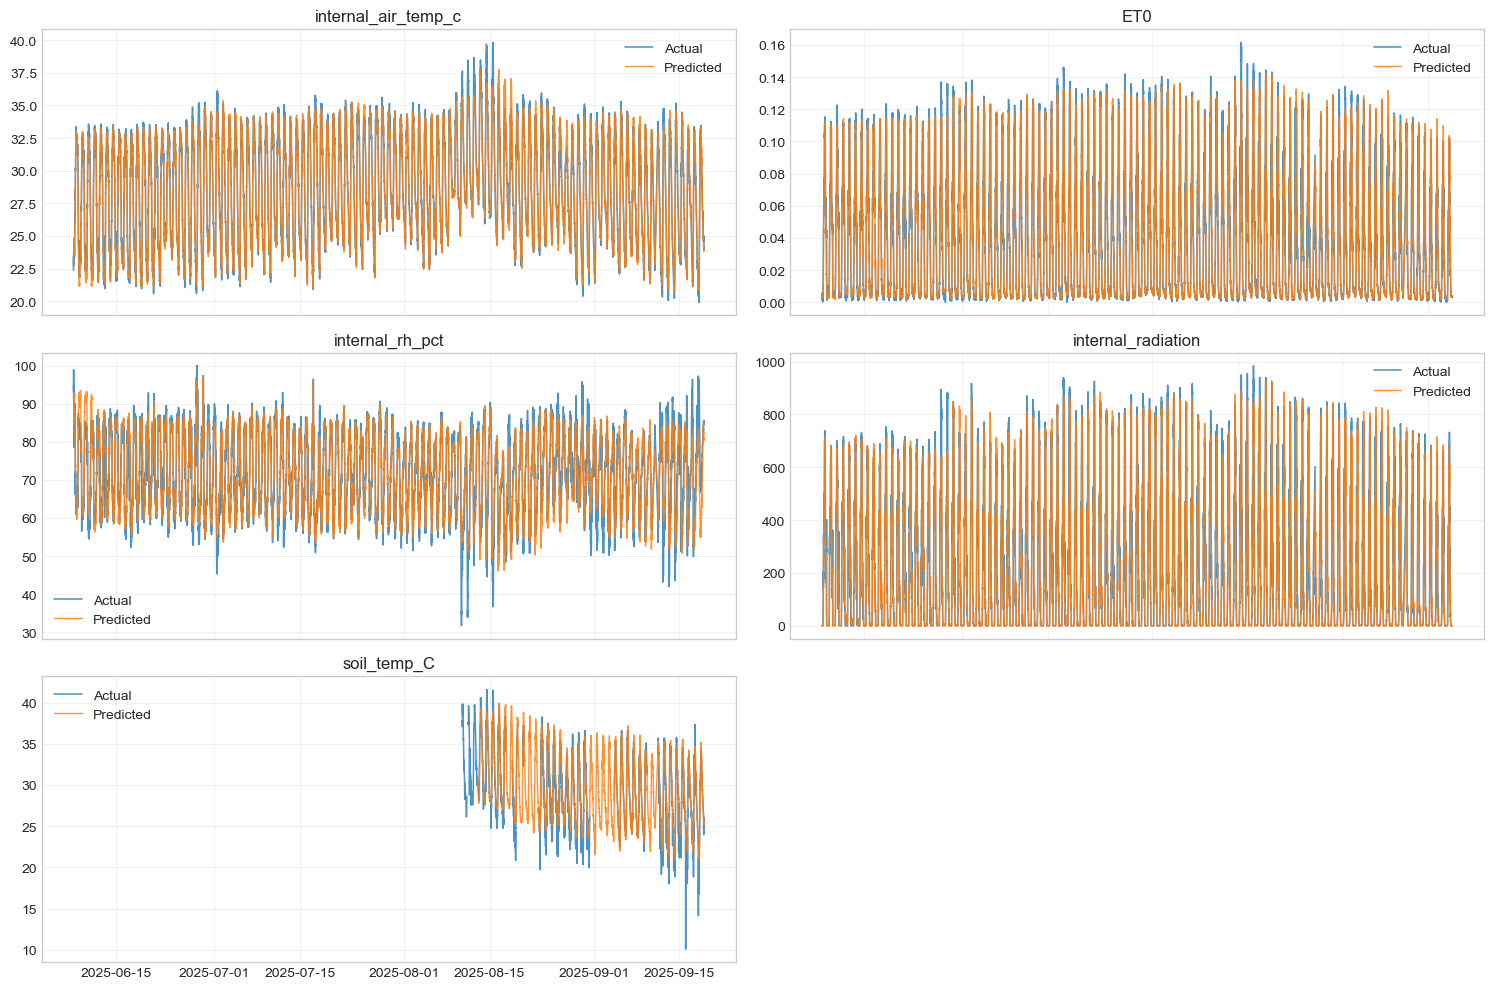

Saved plot to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\plots\micro climate results\micro_climate_3day_unified_actual_vs_predicted.png


In [11]:
# Plot predicted vs actual for all five targets
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
axes = axes.ravel()

for ax, target in zip(axes, TARGETS):
    pred_col = f'pred_{target}'
    sub = preds_df[['timestamp', target, pred_col]].copy()
    ax.plot(sub['timestamp'], sub[target], label='Actual', linewidth=1.1, alpha=0.8)
    ax.plot(sub['timestamp'], sub[pred_col], label='Predicted', linewidth=1.0, alpha=0.85)
    ax.set_title(target)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.25)

for ax in axes[len(TARGETS):]:
    ax.set_visible(False)

plt.tight_layout()
plot_path = PLOTS / 'micro_climate_3day_unified_actual_vs_predicted.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved plot to', plot_path)


Saved feature importance to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\data\processed\MicroClimate_feature_importance_all_targets_3day.csv


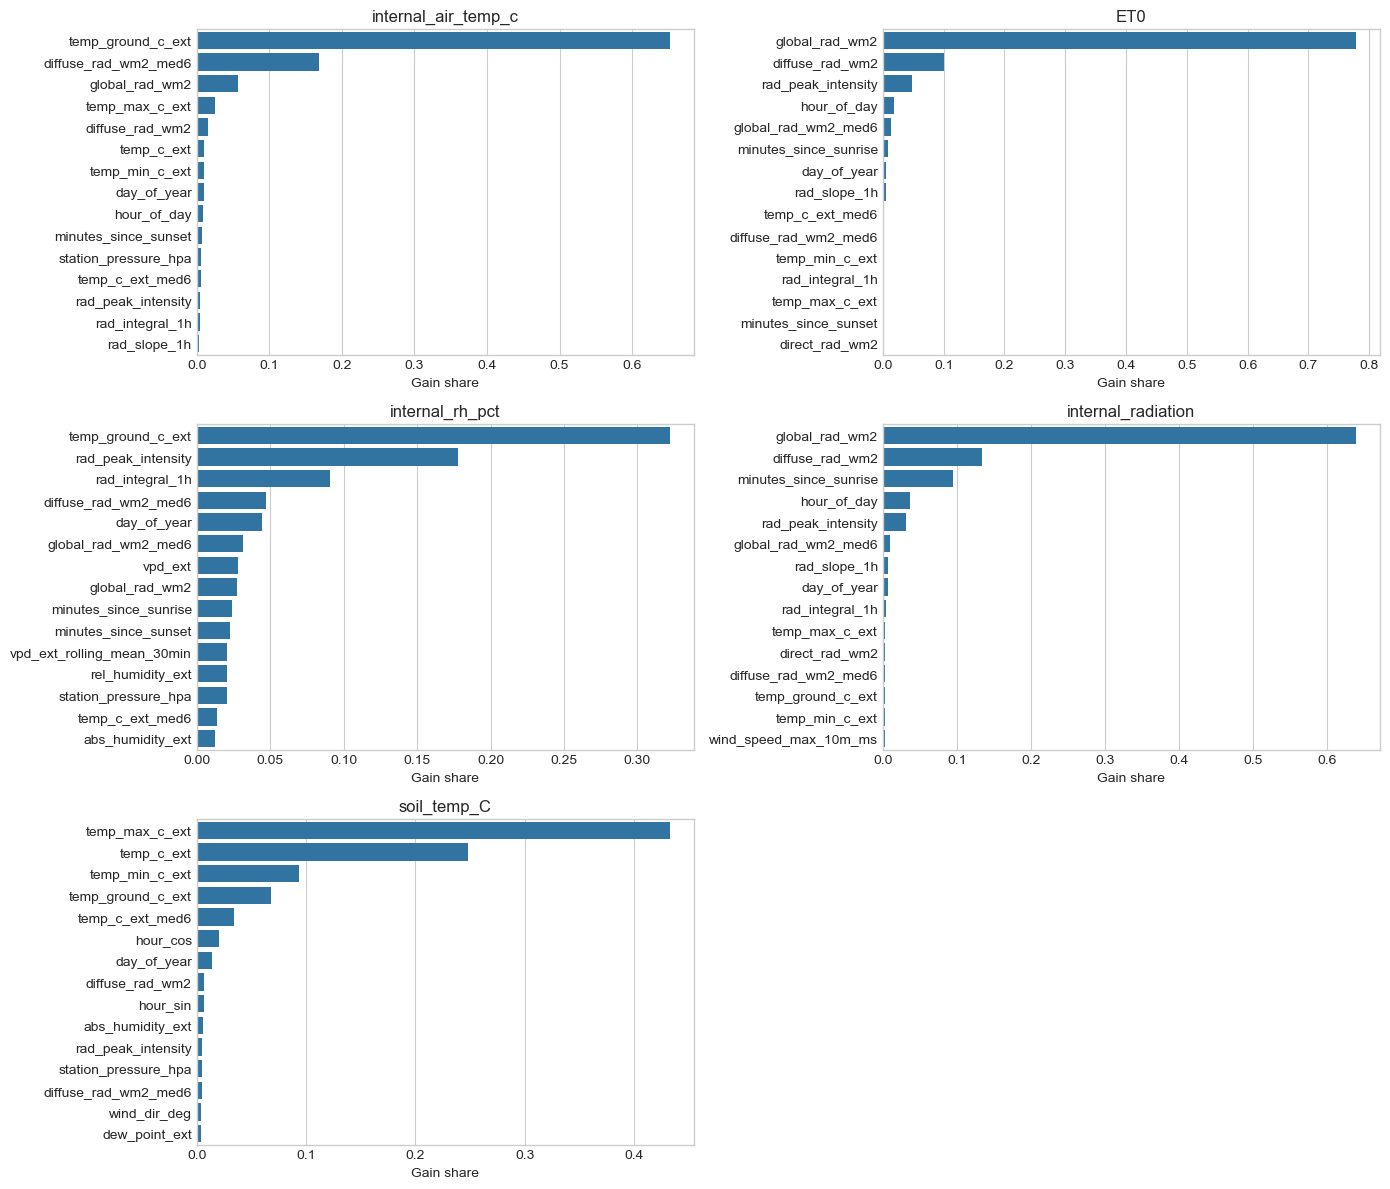

Saved plot to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\plots\micro climate results\micro_climate_3day_unified_feature_importance.png


In [14]:
# Feature importance per target, trained once on all available rows for that target
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
importance_rows = []
for target in TARGETS:
    train_t = model_frame.dropna(subset=[target])
    if len(train_t) < MIN_TRAIN_ROWS_PER_TARGET:
        print(f'{target}: skipped feature importance, only {len(train_t)} train rows')
        continue
    model_t = clone(estimator_for_target(target))
    cols_t = feature_cols_for_target(target)
    model_t.fit(train_t[cols_t], train_t[target])
    gain = model_t.booster_.feature_importance(importance_type='gain')
    sub = pd.DataFrame({'target': target, 'feature': cols_t, 'importance_gain': gain})
    total = sub['importance_gain'].sum()
    sub['importance_share'] = sub['importance_gain'] / total if total else 0
    importance_rows.append(sub)

importance_df = pd.concat(importance_rows, ignore_index=True)
importance_path = PROCESSED / f'{OUTPUT_PREFIX}_feature_importance_all_targets_3day.csv'
importance_df.to_csv(importance_path, index=False)
print('Saved feature importance to', importance_path)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()
for ax, target in zip(axes, TARGETS):
    sub = importance_df[importance_df['target'] == target].sort_values('importance_share', ascending=False).head(15)
    sns.barplot(x='importance_share', y='feature', data=sub, ax=ax, color='tab:blue')
    ax.set_title(target)
    ax.set_xlabel('Gain share')
    ax.set_ylabel('')
for ax in axes[len(TARGETS):]:
    ax.set_visible(False)
plt.tight_layout()
fi_plot_path = PLOTS / 'micro_climate_3day_unified_feature_importance.png'
plt.savefig(fi_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved plot to', fi_plot_path)


In [15]:
# Train final models on all available labeled rows, predict full range, and save one deployment bundle.
final_preds = model_frame[['timestamp']].copy()
final_model_rows = []
final_models = {}

for target in TARGETS:
    train_t = model_frame.dropna(subset=[target])
    pred_col = f'pred_{target}'
    final_preds[pred_col] = np.nan

    if len(train_t) < MIN_TRAIN_ROWS_PER_TARGET:
        print(f'{target}: skipped final model, only {len(train_t)} train rows')
        continue

    model_t = clone(estimator_for_target(target))
    cols_t = feature_cols_for_target(target)
    model_t.fit(train_t[cols_t], train_t[target])
    final_models[target] = model_t
    final_preds[pred_col] = clip_predictions(target, model_t.predict(model_frame[cols_t]))
    final_model_rows.append({
        'variable': target,
        'train_rows': len(train_t),
        'train_start': train_t['timestamp'].min(),
        'train_end': train_t['timestamp'].max(),
        'feature_count': len(cols_t),
    })

final_model_info = pd.DataFrame(final_model_rows)
final_preds_path = PROCESSED / f'{OUTPUT_PREFIX}_final_predictions_all_targets_3day.csv'
final_info_path = PROCESSED / f'{OUTPUT_PREFIX}_final_model_training_rows_3day.csv'
model_path = PROCESSED / 'micro_climate_3day_unified_model.joblib'

final_preds.to_csv(final_preds_path, index=False)
final_model_info.to_csv(final_info_path, index=False)
joblib.dump({
    'models': final_models,
    'feature_cols': feature_cols,
    'base_feature_cols': base_feature_cols,
    'soil_feature_cols': soil_feature_cols,
    'feature_cols_by_target': feature_cols_by_target,
    'target_cols': TARGETS,
    'model_params_by_target': {target: estimator_for_target(target).get_params() for target in TARGETS},
    'train_window': TRAIN_WINDOW,
    'test_window': TEST_WINDOW,
    'frequency': '10min',
}, model_path)

display(final_model_info)
print('Saved final full-range predictions to', final_preds_path)
print('Saved final model info to', final_info_path)
print('Saved model bundle to', model_path)


,variable,train_rows,train_start,train_end,feature_count
0,internal_air_temp_c,16541,2025-05-29 01:00:00,2025-09-21 23:00:00,33
1,ET0,16541,2025-05-29 01:00:00,2025-09-21 23:00:00,33
2,internal_rh_pct,16541,2025-05-29 01:00:00,2025-09-21 23:00:00,33
3,internal_radiation,16541,2025-05-29 01:00:00,2025-09-21 23:00:00,33
4,soil_temp_C,4231,2025-08-10 12:30:00,2025-09-19 18:10:00,37


Saved final full-range predictions to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\data\processed\MicroClimate_final_predictions_all_targets_3day.csv
Saved final model info to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\data\processed\MicroClimate_final_model_training_rows_3day.csv
Saved model bundle to c:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\data\processed\micro_climate_3day_unified_model.joblib
